## Exercise 1.4 Hotdog -- no hotdog
This is the poster hand-in project for the course. Please see the associated PDF for instructions.

In [1]:
import os
import numpy as np
import glob
import PIL.Image as Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torchvision.models as models

We always check that we are running on a GPU

In [2]:
if torch.cuda.is_available():
    print("The code will run on GPU.")
else:
    print("The code will run on CPU. Go to Edit->Notebook Settings and choose GPU as the hardware accelerator")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

The code will run on CPU. Go to Edit->Notebook Settings and choose GPU as the hardware accelerator


We provide you with a class that can load the *hotdog/not hotdog* dataset you should use from /dtu/datasets1/02516/

In [2]:

# torch.utils.data.Dataset : new class that inherits from torch.utils.data.Dataset and override the __len__ and __getitem__ functions, so that it can be used as input to a torch.utils.data.DataLoader instance.
# We override with our own methods so can be used in Pytorch DataLoader
class Hotdog_NotHotdog(torch.utils.data.Dataset):


    def __init__(self, train, transform, data_path=r'C:\Users\leahi\Documents\DTU\IDLCV Projects\02516---Deep-learning-in-Computer-Vision\Project_1\hotdog_nothotdog\hotdog_nothotdog'):
        'Initialization'
        self.transform = transform
        data_path = os.path.join(data_path, 'train' if train else 'test')
        # Convert backslashes to forward slashes for glob on Windows
        data_path = data_path.replace('\\', '/')
        image_classes = [os.path.split(d)[1] for d in glob.glob(data_path +'/*') if os.path.isdir(d)]
        image_classes.sort()
        self.name_to_label = {c: id for id, c in enumerate(image_classes)}
        self.image_paths = glob.glob(data_path + '/*/*.jpg')
        
    def __len__(self):
        'Returns the total number of samples'
        return len(self.image_paths)

    def __getitem__(self, idx):
        'Generates one sample of data'
        image_path = self.image_paths[idx]
        
        image = Image.open(image_path)
        c = os.path.split(os.path.split(image_path)[0])[1]
        y = self.name_to_label[c]
        X = self.transform(image)
        return X, y

Below is the simple way of converting the images to something that can be fed through a network.
Feel free to use something other than $128\times128$ images.

In [3]:
size = 128
train_transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.ToTensor()])

batch_size = 64

#Now we use the class we define above to load the data
# then use DataLoader to load data in batches and shuffle the data for training, and not shuffle for testing
trainset = Hotdog_NotHotdog(train=True, transform=train_transform)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0)
testset = Hotdog_NotHotdog(train=False, transform=test_transform)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0)

Let's look at some images from our data 

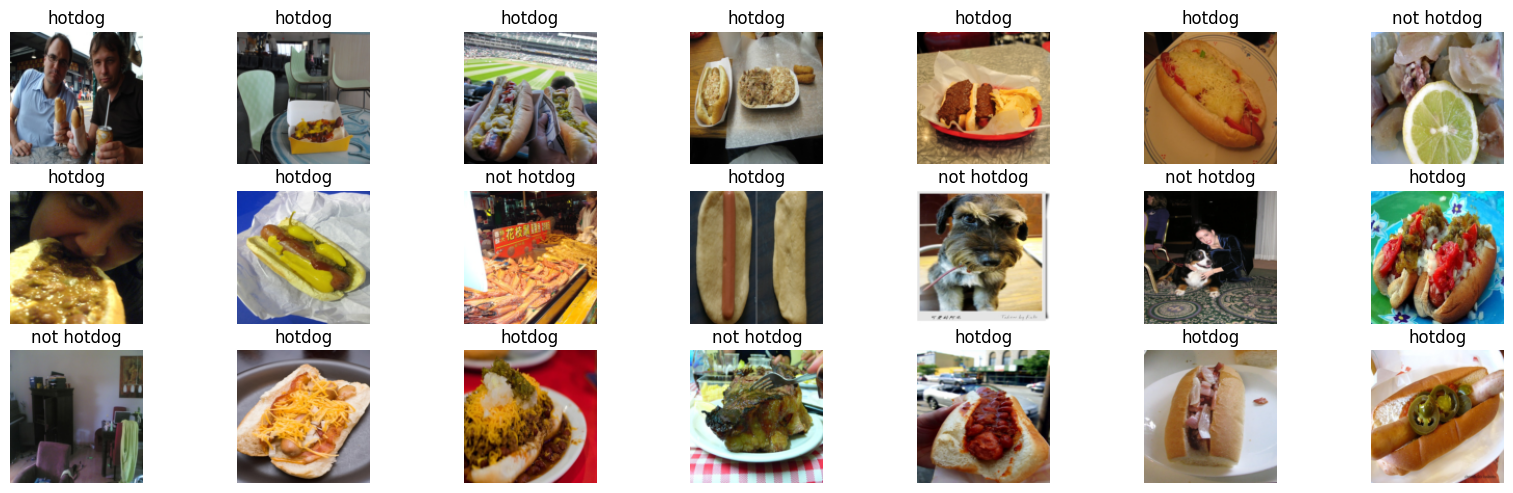

In [4]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(20,10))

for i in range(21):
    plt.subplot(5,7,i+1)
    plt.imshow(np.swapaxes(np.swapaxes(images[i].numpy(), 0, 2), 0, 1))
    plt.title(['hotdog', 'not hotdog'][labels[i].item()])
    plt.axis('off')


## Model architecture and Training

In [5]:
model = models.resnet18(pretrained=True)

# Freeze all layers (don't update during training)
# We want to use the pretrained ResNet18 as a feature extractor, so we freeze all layers to prevent their weights from being updated during training. 
# This allows us to only train the final layer that we will replace for our specific task.
for param in model.parameters():
    param.requires_grad = False

# Replace final layer for binary classification (hotdog vs not hotdog)
# That why parameter is 2, because we have 2 classes: hotdog and not hotdog
model.fc = nn.Linear(model.fc.in_features, 2)

c:\Users\leahi\Documents\DTU\IDLCV Projects\02516---Deep-learning-in-Computer-Vision\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\leahi\Documents\DTU\IDLCV Projects\02516---Deep-learning-in-Computer-Vision\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
# Loss function and optimizer (only optimize the final layer)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

# Training loop
num_epochs = 5
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
        # Move data to device
        images, labels = images.to(device), labels.to(device)
        
        # Zero the gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        # Track statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    print(f'Epoch {epoch+1}: Loss = {epoch_loss:.4f}, Accuracy = {epoch_acc:.2f}%')

Epoch 1/5:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1: Loss = 0.5423, Accuracy = 72.59%


Epoch 2/5:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 2: Loss = 0.3343, Accuracy = 85.74%


Epoch 3/5:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 3: Loss = 0.2912, Accuracy = 87.84%


Epoch 4/5:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 4: Loss = 0.2599, Accuracy = 88.81%


Epoch 5/5:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 5: Loss = 0.2430, Accuracy = 90.18%


In [8]:
# Evaluate on test set
model.eval()
correct = 0
total = 0

with torch.no_grad():  # Don't compute gradients during evaluation
    for images, labels in tqdm(test_loader, desc='Testing'):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f'Test Accuracy: {test_accuracy:.2f}%')

Testing:   0%|          | 0/30 [00:00<?, ?it/s]

Test Accuracy: 88.51%


In [ ]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, num_epochs+1), train_losses, 'b-o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')

ax2.plot(range(1, num_epochs+1), train_accuracies, 'g-o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training Accuracy')

plt.tight_layout()
plt.show()

In [ ]:
# Visualize some predictions
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)

plt.figure(figsize=(20, 10))
for i in range(21):
    plt.subplot(5, 7, i+1)
    img = images[i].cpu().numpy()
    plt.imshow(np.swapaxes(np.swapaxes(img, 0, 2), 0, 1))
    
    true_label = ['hotdog', 'not hotdog'][labels[i].item()]
    pred_label = ['hotdog', 'not hotdog'][predicted[i].item()]
    color = 'green' if labels[i] == predicted[i] else 'red'
    plt.title(f'True: {true_label}\nPred: {pred_label}', color=color, fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()